In [3]:
import os
import sys

print(os.getcwd())
# 1. Navigate UP two levels to the project root:
#    preparation/ -> CST-Part-II-Project-Code/
os.chdir('..') # Go up one level (out of preparation)

# 2. Check the path again. We should now be in the project root.
#    You don't need to go up another level, as the previous failed attempt
#    must have been a result of not resetting the environment first.
#    We will confirm and then add the current directory ('.').

# 3. Add the project root (the directory containing 'src') to sys.path
#    The '.' refers to the Current Working Directory, which is now the project root.
#if '.' not in sys.path:
#    sys.path.append('.')

# Check the final working directory (optional, but helpful for confirmation)
print(f"New CWD for imports: {os.getcwd()}")
print("System path successfully configured.")

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code\preparation
New CWD for imports: C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code
System path successfully configured.


In [2]:
%pip install stim
%pip install svgwrite


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from src.color_code_utils.color_code_circuits.color_code_circuit_666 import ColorCodeCircuit666

In [3]:
#circ = ColorCodeCircuit666()
layout = circ.generate_layout(3)

NameError: name 'circ' is not defined

In [ ]:
from dataclasses import dataclass
import stim
@dataclass
class ColorCodeTile:
    qubits: list
    ancilla: tuple
    color: str
class ColorCodeCircuit666Test:
    def within_bounds(self,x,y,side):
        if y<0:
            return False
        if x<y:
            return False
        if y>(side-1)-x:
            return False
        return True
        
    def generate_layout(self, distance:int):
        side = distance*3 - 2
        xtype = [['D', 'D', 'M'], ['M','D','D'], ['D','M','D']]
        dirs = [(-1,-1), (1,-1),(2,0),(1,1),(-1,1),(-2,0)]
        tiles = []
        validpos = set()
        for y in range(0, side):
            xpattern = xtype[y % 3]
            patternptr = 0
            for x in range(y,side-y,2):
                #print(x,y)
                currtype = xpattern[patternptr % 3]
                if currtype == 'M':
                    tile = ColorCodeTile(
                        qubits = [(x+dx, y+dy) for dx,dy in dirs if self.within_bounds(x+dx,y+dy,side)],
                        ancilla = (x,y),
                        color = ['red','green','blue'][y % 3])
                    tiles.append(tile)
                patternptr += 1
        return tiles

    # based on https://github.com/quantumlib/chromobius/blob/main/doc/getting_started.ipynb
    def build_chrom_circuit(self, rounds:int, distance:int, after_clifford_depolarization:float, observable_basis=str):
       #'''Building a circuit using the chromobius docs - these don't explicitly use/declare ancilla qubits'''
        
        def mpp_targets(qubits:list, basis:str):
            '''Makes a pauli product for an MPP instruction '''
            target_basis = {'X':stim.target_x, 'Z':stim.target_z}[basis]
            idxs = sorted(qa_index_map[q] for q in qubits)
            targets = []
            for i in idxs:
                targets.append(target_basis(i))
                targets.append(stim.target_combiner())
            targets.pop()  # remove last combiner
            return targets
            
        def measure_observables():
            c = stim.Circuit()
            c.append("MPP", mpp_targets(sorted(qubits), observable_basis))
            c.append("OBSERVABLE_INCLUDE", stim.target_rec(-1), 0)
            return c
            
        def measure_stabilizers():
            c = stim.Circuit()

            for basis in ['X','Z']:
                for tile in tiles:
                    c.append("MPP", mpp_targets(tile.qubits, basis))
            
            num_stabilizers = len(tiles)*2
            for xz in range(2):
                for k, tile in enumerate(tiles):
                    ancilla  = tile.ancilla
                    chrom_color = {'red':0,'green':1,'blue':2}[tile.color]
                    chrom_annotation = chrom_color + 3*xz
                    offset = xz*len(tiles) + k
                    c.append("DETECTOR", [stim.target_rec(-(num_stabilizers - offset)), 
                                           stim.target_rec(-num_stabilizers*2+offset)],
                                           [ancilla[0], ancilla[1], 0, chrom_annotation])
            c.append("SHIFT_COORDS", [], [0,0,1])
            c.append("TICK")
            
            return c
        
        tiles = self.generate_layout(distance)
        
        qubits = {q for tile in tiles for q in tile.qubits}
        ancillae = {tile.ancilla for tile in tiles}
        sorted_q_a = sorted(qubits | ancillae)
        qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
        color_tiles = {'red':[tile for tile in tiles if tile.color=='red'],
                       'green':[tile for tile in tiles if tile.color=='green'],
                       'blue':[tile for tile in tiles if tile.color=="blue"]
                       }
        circuit = stim.Circuit()

        for q in qubits:
            idx = qa_index_map[q]
            circuit.append("QUBIT_COORDS", [idx], [q[0], q[1]])

        circuit += measure_observables()
        circuit += measure_stabilizers()
        circuit += (rounds-1) * measure_stabilizers()
        circuit += measure_stabilizers()
        circuit += measure_observables()

        return circuit

    def measure_stabilizers(self, circuit:stim.Circuit, tiles:dict, qa_index_map:dict, basis:str):
        ### group by edge orientation
        measure_dirs = [(1,-1),(2,0),(-1,-1),(1,1),(-2,0),(-1,1)]
        # collect all edges doing CNOTs in these dirs + do them together
        measured_a = []
        cnot_groups = {i:[] for i in range(6)}
        print(f"tiles {tiles}")
        for tile in tiles:
            (a1,a2) = tile.ancilla
            a_idx = qa_index_map[tile.ancilla]
            measured_a.append(a_idx)
            for i in range(6):
                (dx,dy) = measure_dirs[i]
                q = (a1+dx,a2+dy)
                if q in tile.qubits:
                    q_idx = qa_index_map[q]
                    if basis == 'X':
                        cnot_groups[i].extend([a_idx, q_idx])
                    else:
                        cnot_groups[i].extend([q_idx, a_idx])

        for i,group in cnot_groups.items():
            # add instruction to do CNOTs
            circuit.append("CNOT", group)
            circuit.append("TICK")
        if basis=='X':
            circuit.append("MRX", measured_a)
        else:
            circuit.append("MR", measured_a)

    def measure_stabilizers1(self, circuit:stim.Circuit, color:str, color_tiles:dict, qa_index_map:dict, basis:str):
        tilelist = color_tiles[color]
        ancilla_idxs = [qa_index_map[tile.ancilla] for tile in tilelist]

        
        #reset
        circuit.append("R", ancilla_idxs)
        circuit.append("TICK")
        # prepare ancilla qubits in the correct basis
        if basis == 'X':
            circuit.append("H", ancilla_idxs)
            circuit.append("TICK")

        cnot_ops = []
        for tile in tilelist:
            ancilla_idx = qa_index_map[tile.ancilla]
            for q in tile.qubits:
                data_idx = qa_index_map[q]
                if basis == 'X':
                    cnot_ops.extend([ancilla_idx, data_idx])
                else:
                    cnot_ops.extend([data_idx, ancilla_idx])
        if cnot_ops:
            circuit.append("CNOT", cnot_ops)
            circuit.append("TICK")
        
        #measurement
        circuit.append("M", ancilla_idxs)

        return ancilla_idxs

    def measure_rounds(self, circuit:stim.Circuit, tiles:dict, qa_index_map:dict, measures_per_round:int):
        loop = stim.Circuit()
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}

        # X 
        self.measure_stabilizers(loop,tiles,qa_index_map, 'X')
        for i, tile in enumerate(tiles):
            current_offset = -(len(tiles) - i)
            prev_offset = current_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(current_offset), stim.target_rec(prev_offset)], [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color]['X']])

        loop.append("TICK")
        
        # Z
        self.measure_stabilizers(loop,tiles,qa_index_map, 'Z')
        for i, tile in enumerate(tiles):
            current_offset = -(len(tiles) - i)
            prev_offset = current_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(current_offset), 
                                     stim.target_rec(prev_offset)], [tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])
        loop.append("TICK")
        loop.append("SHIFT_COORDS", [], [0,0,1])
        return loop

    def measure_round_Z_0(self, tiles:dict, qa_index_map:dict):
        loop = stim.Circuit()
        total_m  = len(tiles)
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}

        self.measure_stabilizers(loop,tiles,qa_index_map,'Z')
        for i, tile in enumerate(tiles):
            loop.append("DETECTOR", [stim.target_rec(-(total_m - i))],[tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])

        loop.append("TICK")
        loop.append("SHIFT_COORDS", [], [0,0,1])
        return loop
        
    def measure_rounds1(self, circuit:stim.Circuit, color_tiles:dict, qa_index_map:dict, measures_per_round:int):
        current_measure = 0
        loop = stim.Circuit()
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}

        for color, tilelist in color_tiles.items():
            ancilla_idxs = self.measure_stabilizers(loop, color, color_tiles, qa_index_map, basis='X')

            for i,tile in enumerate(tilelist):
                rec1 = stim.target_rec(-(len(ancilla_idxs)-i))
                rec2 = stim.target_rec(-(len(ancilla_idxs)-i+measures_per_round))

                loop.append("DETECTOR", [rec1, rec2], [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[color]['X']])
            current_measure += len(ancilla_idxs)
            loop.append("TICK")

            # Z basis 
            ancilla_idxs = self.measure_stabilizers(loop, color, color_tiles, qa_index_map, basis='Z')

            for i,tile in enumerate(tilelist):
                rec1 = stim.target_rec(-(len(ancilla_idxs)-i))
                rec2 = stim.target_rec(-(len(ancilla_idxs)-i+measures_per_round))

                loop.append("DETECTOR", [rec1, rec2], [tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[color]['Z']])
            current_measure += len(ancilla_idxs)
            loop.append("TICK")
            
        return loop

    def build_circuit(self, rounds:int, distance:int, after_clifford_depolarization:float):
        tiles = self.generate_layout(distance)
        print(f"generated layout: {tiles}")
        circ = stim.Circuit()

        qubits = {q for tile in tiles for q in tile.qubits}
        ancillae = {tile.ancilla for tile in tiles}
        sorted_q_a = sorted(qubits | ancillae)
        qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}
        colors = ['red','green','blue']
        
        # append coords to the circuit
        for q,i in qa_index_map.items():
            circ.append("QUBIT_COORDS", [i], [q[0], q[1]])

        # reset everything
        circ.append("R", [qa_index_map[q] for q in qubits])
        circ.append("R", [qa_index_map[a] for a in ancillae])
        circ.append("TICK")
        
        # round 0:
        self.measure_stabilizers(circ, tiles, qa_index_map, 'X')
        circ += self.measure_round_Z_0(tiles, qa_index_map)

        
        circ += (rounds-1) * self.measure_rounds(circ, tiles, qa_index_map, measures_per_round=2*len(tiles))

        # measure qubits
        sorted_qs = sorted(list(qubits))
        q_idxs = [qa_index_map[q] for q in sorted_qs]
        circ.append("M", q_idxs)
        
        # final z-detectors
        q_rec_offsets = {q_idx : -len(q_idxs) + k for k,q_idx in enumerate(q_idxs)}
        for i, tile in enumerate(tiles):
            targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in tile.qubits]
            a_offset = -len(q_idxs) - (len(tiles) - i)
            targets.append(stim.target_rec(a_offset))

            circ.append("DETECTOR", targets, [tile.ancilla[0], tile.ancilla[1], 1, chrom_annot[tile.color]['Z']])

        # logical observable
        logical_z_qubits = [q for q in sorted_qs if q[1]==0]
        obs_targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in logical_z_qubits]
        circ.append("OBSERVABLE_INCLUDE", obs_targets, 0)
        
        return circ
        
circ = ColorCodeCircuit666(9,2)
layout = circ._generate_layout(9)
#circ.build_circuit(2,3,0.001)
#circ.build_chrom_circuit(7,3,0.001,'X')
#print(circ.build_chrom_circuit(7,3,0.001,'X').decomposed())
circ.build_circuit()
print(f'\n\n NON CHROM :\n {circ.get_circuit()}')
circ.circuit.diagram("detslice",filter_coords=['D61', 'D73'])

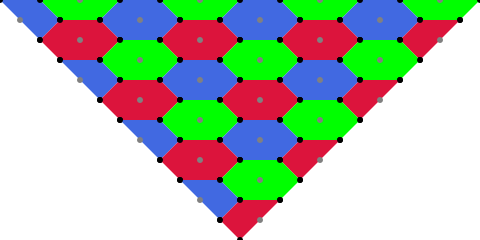

In [4]:
from src.color_code_utils.color_code_circuits.color_code_circuit_666 import ColorCodeCircuit666
import svgwrite
from IPython.display import SVG, display
color_map = {
    'red':'crimson',
    'green':'lime',
    'blue':'royalblue'
    }

CC = ColorCodeCircuit666(3,2)
layout = CC._generate_layout(9)
def draw_tiles(tiles):
    width = max(x for tile in tiles for x,y in tile.qubits)
    height = max(y for tile in tiles for x,y in tile.qubits)
    drawing = svgwrite.Drawing(size = (width*20, height*20))

    for tile in tiles:
        drawing.add(drawing.polygon(
            points = [(x*20, y*20) for x,y in tile.qubits],
            fill = color_map[tile.color]
        ))
        drawing.add(drawing.circle(center=(tile.ancilla[0]*20, tile.ancilla[1]*20), r=3, fill='grey'))
        for x,y in tile.qubits:
            drawing.add(drawing.circle(center=(x*20, y*20), r=3, fill='black'))
    
    svg_data = drawing.tostring()
    display(SVG(svg_data))

draw_tiles(layout)

In [5]:

circuit = stim.Circuit.generated(
      "color_code:memory_xyz",
      rounds=2,
      distance=3,
      after_clifford_depolarization=1e-3
)
print(str(circuit))

NameError: name 'stim' is not defined

In [6]:
circuit = stim.Circuit.generated(
      "color_code:memory_xyz",
      rounds=2,
      distance=5,
      after_clifford_depolarization=1e-3
)
print(str(circuit))

NameError: name 'stim' is not defined

In [8]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(4, 0) 1
QUBIT_COORDS(7, 0) 2
QUBIT_COORDS(9, 0) 3
QUBIT_COORDS(12, 0) 4
QUBIT_COORDS(1, 1) 5
QUBIT_COORDS(3, 1) 6
QUBIT_COORDS(6, 1) 7
QUBIT_COORDS(10, 1) 8
QUBIT_COORDS(4, 2) 9
QUBIT_COORDS(7, 2) 10
QUBIT_COORDS(9, 2) 11
QUBIT_COORDS(6, 3) 12
R 0 1 4 7 8 9 12
X_ERROR(0.001) 0 1 4 7 8 9 12
R 2 5 10
RX 3 6 11
X_ERROR(0.001) 2 5 10
Z_ERROR(0.001) 3 6 11
TICK
CX 1 2 9 10
DEPOLARIZE2(0.001) 1 2 9 10
DEPOLARIZE1(0.001) 0 3 4 5 6 7 8 11 12
TICK
CX 7 2 12 10 3 1 11 9
DEPOLARIZE2(0.001) 7 2 12 10 3 1 11 9
DEPOLARIZE1(0.001) 0 4 5 6 8
TICK
CX 8 2 9 5 3 7 11 12
DEPOLARIZE2(0.001) 8 2 9 5 3 7 11 12
DEPOLARIZE1(0.001) 0 1 4 6 10
TICK
CX 0 5 7 10 3 8 6 9
DEPOLARIZE2(0.001) 0 5 7 10 3 8 6 9
DEPOLARIZE1(0.001) 1 2 4 11 12
TICK
CX 1 5 8 10 6 0 11 7
DEPOLARIZE2(0.001) 1 5 8 10 6 0 11 7
DEPOLARIZE1(0.001) 2 3 4 9 12
TICK
CX 4 2 7 5 6 1 11 8
DEPOLARIZE2(0.001) 4 2 7 5 6 1 11 8
DEPOLARIZE1(0.001) 0 3 9 10 12
TICK
CX 3 4 6 7
DEPOLARIZE2(0.001) 3 4 6 7
DEPOLARIZE1(0.001) 0 

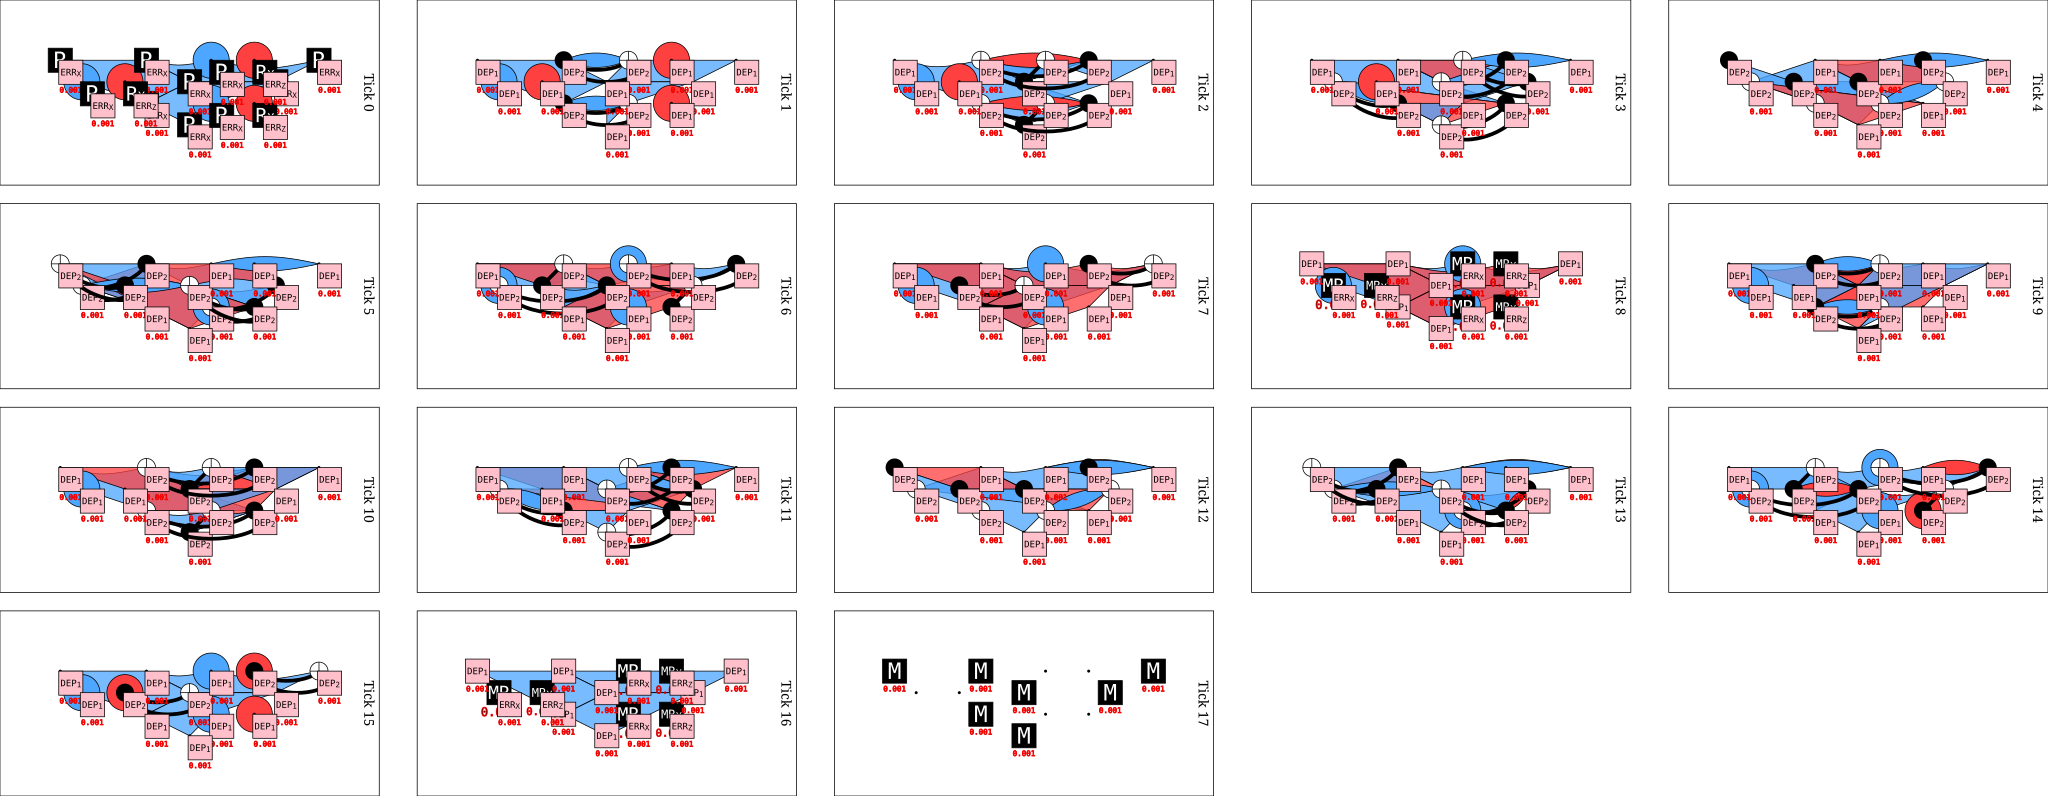

In [5]:
from color_code_stim import ColorCode,NoiseModel
noise = NoiseModel.uniform_circuit_noise(1e-3)
colorcode=ColorCode(d=3,rounds=2,circuit_type="tri", noise_model=noise)
print(str(colorcode.circuit))

(colorcode.circuit).diagram("detslice-with-ops-svg")

In [6]:
cc = ColorCodeCircuit666(3,2,1e-3)
circ = cc.get_circuit()
print(circ)

QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(1, 1) 1
QUBIT_COORDS(2, 0) 2
QUBIT_COORDS(2, 2) 3
QUBIT_COORDS(3, 1) 4
QUBIT_COORDS(3, 3) 5
QUBIT_COORDS(4, 0) 6
QUBIT_COORDS(4, 2) 7
QUBIT_COORDS(5, 1) 8
QUBIT_COORDS(6, 0) 9
R 0 2 3 4 5 8 9
X_ERROR(0.001) 0 2 3 4 5 8 9
R 1 6 7
X_ERROR(0.001) 1 6 7
TICK
RX 6 1 7
Z_ERROR(0.001) 6 1 7
CX 1 0 7 4
DEPOLARIZE2(0.001) 1 0 7 4
DEPOLARIZE1(0.001) 2 3 5 8 9
TICK
CX 1 2 7 8
DEPOLARIZE2(0.001) 1 2 7 8
DEPOLARIZE1(0.001) 0 3 4 5 9
TICK
CX 6 2 7 3
DEPOLARIZE2(0.001) 6 2 7 3
DEPOLARIZE1(0.001) 0 4 5 8 9
TICK
CX 6 9 1 4
DEPOLARIZE2(0.001) 6 9 1 4
DEPOLARIZE1(0.001) 0 2 3 5 8
TICK
CX 6 4 7 5
DEPOLARIZE2(0.001) 6 4 7 5
DEPOLARIZE1(0.001) 0 2 3 8 9
TICK
CX 6 8 1 3
DEPOLARIZE2(0.001) 6 8 1 3
DEPOLARIZE1(0.001) 0 2 4 5 9
TICK
MX 6 1 7
DEPOLARIZE1(0.001) 0 2 3 4 5 8 9
R 6 1 7
X_ERROR(0.001) 6 1 7
CX 0 1 4 7
DEPOLARIZE2(0.001) 0 1 4 7
DEPOLARIZE1(0.001) 2 3 5 8 9
TICK
CX 2 1 8 7
DEPOLARIZE2(0.001) 2 1 8 7
DEPOLARIZE1(0.001) 0 3 4 5 9
TICK
CX 2 6 3 7
DEPOLARIZE2(0.001) 2 6 

Starting 4 workers...
25 tasks left:
  workers    decoder eta shots_left errors_left json_metadata     
        1 chromobius   ?   10000000         500 d=3,p=0.0001,r=12 
        1 chromobius   ?   10000000         500 d=3,p=0.001,r=12  
        1 chromobius   ?    9999727         468 d=3,p=0.002,r=12  
        1 chromobius   ?   10000000         500 d=3,p=0.005,r=12  
        0 chromobius ?·∞   10000000         500 d=3,p=0.01,r=12   
        0 chromobius ?·∞   10000000         500 d=5,p=0.0001,r=20 
        0 chromobius ?·∞   10000000         500 d=5,p=0.001,r=20  
        0 chromobius ?·∞   10000000         500 d=5,p=0.002,r=20  
        0 chromobius ?·∞   10000000         500 d=5,p=0.005,r=20  
        0 chromobius ?·∞   10000000         500 d=5,p=0.01,r=20   
        0 chromobius ?·∞   10000000         500 d=7,p=0.0001,r=28 
        0 chromobius ?·∞   10000000         500 d=7,p=0.001,r=28  
        0 chromobius ?·∞   10000000         500 d=7,p=0.002,r=28  
        0 chromobius ?·∞ 

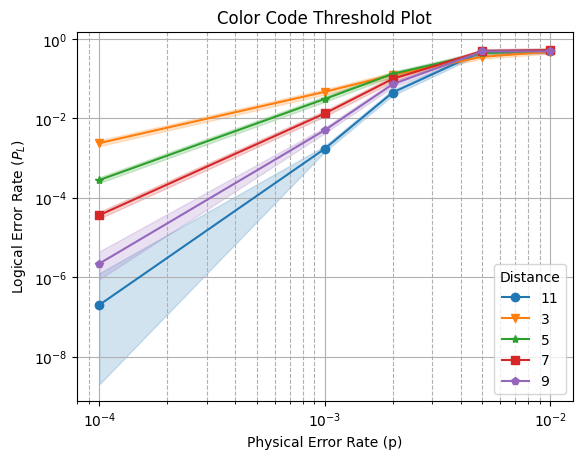

In [7]:
import sinter
import matplotlib.pyplot as plt
from typing import List
import chromobius

def generate_plot():
    distances = [3, 5, 7]
    noise_levels = [0.0001, 0.001, 0.002, 0.005, 0.01]
    
    tasks = [
        sinter.Task(
            circuit=ColorCodeCircuit666(d,r,p).get_circuit(),
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in [3, 5, 7, 9, 11]
        for r in [d*4]
        for p in noise_levels
    ]

    # sampling
    samples = sinter.collect(
        tasks=tasks,
        num_workers=os.cpu_count(),
        max_shots=10_000_000,
        max_errors=500,
        print_progress=True,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    # plotting
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1,  # Probability per shot
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    ax.legend(title='Distance')
    plt.savefig("ImplCCThresholdPlot")
    plt.show()
generate_plot()

In [35]:
def generate_plot2():
    # We want to test multiple distances and multiple noise levels.
    distances = [3, 5, 7]
    noise_levels = [0.001, 0.002, 0.005, 0.01]
    
    tasks = [
        sinter.Task(
            circuit=ColorCode(d=d,rounds=r,circuit_type="tri", noise_model=NoiseModel.uniform_circuit_noise(p)).circuit,
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in [3, 5, 7, 9, 11]
        for r in [d*4]
        for p in noise_levels
    ]

    # Run the samples
    samples = sinter.collect(
        tasks=tasks,
        num_workers=os.cpu_count(),
        max_shots=100_000,
        max_errors=500,
        print_progress=True,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    # plots
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1,  # Probability per shot
    )

    ax.loglog()
    ax.set_title("Library Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    ax.legend(title='Distance')
    plt.savefig("LibCCThresholdPlot")
    plt.show()
generate_plot2()

Starting 4 workers...


RuntimeError: Worker failed: traceback=Traceback (most recent call last):
  File "C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\venv\Lib\site-packages\sinter\_collection\_collection_worker_state.py", line 243, in run_message_loop
    num_messages_processed = self.process_messages()
                             ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\venv\Lib\site-packages\sinter\_collection\_collection_worker_state.py", line 182, in process_messages
    self.change_job(new_task=new_task, new_collection_options=new_collection_options)
  File "C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\venv\Lib\site-packages\sinter\_collection\_collection_worker_state.py", line 145, in change_job
    self.compiled_sampler = self.sampler.compiled_sampler_for_task(self.current_task)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\venv\Lib\site-pack

In [30]:
def generate_split_plot():
    # --- Collection A: My Code with BP-OSD ---
    noise_levels = [0.001, 0.002, 0.005, 0.01]
    tasks_my_code = [
        sinter.Task(
            circuit=ColorCodeCircuit666(d, d, p).get_circuit(),
            json_metadata={'d': d, 'p': p, 'source': 'My Code'}
        )
        for d in [3, 5, 7, 9, 11]
        for r in [d*4]
        for p in noise_levels
    ]
    
    samples_A = sinter.collect(
        tasks=tasks_my_code,
        num_workers=4,
        max_shots=1000,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    # --- Collection B: Library with Pymatching (e.g., if it supports decomposition) ---
    tasks_lib = [
        sinter.Task(
            circuit=ColorCode(d=d,rounds=r,circuit_type="tri", noise_model=NoiseModel.uniform_circuit_noise(p)).circuit,
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in [3, 5, 7, 9, 11]
        for r in [d*4]
        for p in noise_levels
    ]

    # Run the samples
    samples = sinter.collect(
        tasks=tasks_lib,
        num_workers=os.cpu_count(),
        max_shots=100_000,
        max_errors=500,
        print_progress=True,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    # --- Combine and Plot ---
    all_samples = samples_A + samples_B # Merge lists
    
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=all_samples,
        x_func=lambda s: s.json_metadata['p'],
        # Group by Source is enough here, or include decoder if you want
        group_func=lambda s: f"{s.json_metadata['source']} ({s.decoder}) d={s.json_metadata['d']}",
        failure_units_per_shot_func=lambda s: 1,
    )
    ax.set_loglog()
    plt.show()

generate_split_plot()

Starting 4 workers...


RuntimeError: Worker failed: traceback=Traceback (most recent call last):
  File "C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\venv\Lib\site-packages\sinter\_collection\_collection_worker_state.py", line 243, in run_message_loop
    num_messages_processed = self.process_messages()
                             ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\venv\Lib\site-packages\sinter\_collection\_collection_worker_state.py", line 182, in process_messages
    self.change_job(new_task=new_task, new_collection_options=new_collection_options)
  File "C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\venv\Lib\site-packages\sinter\_collection\_collection_worker_state.py", line 145, in change_job
    self.compiled_sampler = self.sampler.compiled_sampler_for_task(self.current_task)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\venv\Lib\site-pack